In [ ]:
!apt-get install -y fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = '/content/drive/MyDrive/power_forecast/'

train_df    = pd.read_csv(DATA_DIR + 'train.csv')
test_df     = pd.read_csv(DATA_DIR + 'test.csv')
building_df = pd.read_csv(DATA_DIR + 'building_info.csv')

print('로드 완료')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
로드 완료


In [ ]:
print('=== train 기본 정보 ===')
print(f'행 수: {len(train_df):,}  |  열 수: {train_df.shape[1]}')
print(f'기간: {train_df["일시"].min()} ~ {train_df["일시"].max()}')
print()
print('=== test 기본 정보 ===')
print(f'행 수: {len(test_df):,}  |  열 수: {test_df.shape[1]}')
print(f'기간: {test_df["일시"].min()} ~ {test_df["일시"].max()}')
print()
print('=== 컬럼 목록 ===')
print('train:', train_df.columns.tolist())
print('test :', test_df.columns.tolist())
print()
print('=== 결측치 ===')
print(train_df.isnull().sum())

=== train 기본 정보 ===
행 수: 204,000  |  열 수: 10
기간: 20240601 00 ~ 20240824 23

=== test 기본 정보 ===
행 수: 16,800  |  열 수: 7
기간: 20240825 00 ~ 20240831 23

=== 컬럼 목록 ===
train: ['num_date_time', '건물번호', '일시', '기온(°C)', '강수량(mm)', '풍속(m/s)', '습도(%)', '일조(hr)', '일사(MJ/m2)', '전력소비량(kWh)']
test : ['num_date_time', '건물번호', '일시', '기온(°C)', '강수량(mm)', '풍속(m/s)', '습도(%)']

=== 결측치 ===
num_date_time    0
건물번호             0
일시               0
기온(°C)           0
강수량(mm)          0
풍속(m/s)          0
습도(%)            0
일조(hr)           0
일사(MJ/m2)        0
전력소비량(kWh)       0
dtype: int64


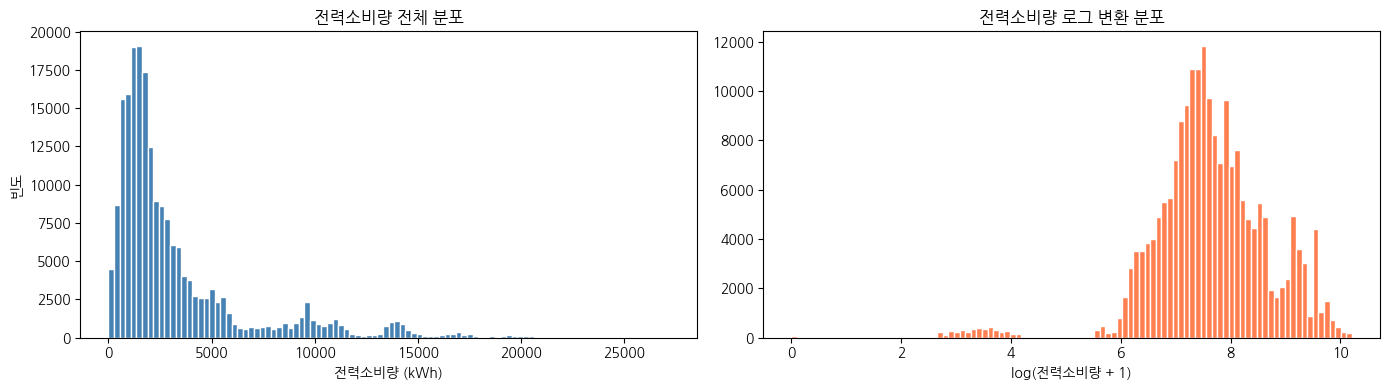

count    204000.00
mean       3329.58
std        3689.10
min           0.00
25%        1176.12
50%        1935.72
75%        3726.76
max       27155.94
Name: 전력소비량(kWh), dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 전체 분포
axes[0].hist(train_df['전력소비량(kWh)'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('전력소비량 전체 분포')
axes[0].set_xlabel('전력소비량 (kWh)')
axes[0].set_ylabel('빈도')

# 로그 스케일 분포 (치우침이 심할 때 더 잘 보임)
axes[1].hist(np.log1p(train_df['전력소비량(kWh)']), bins=100, color='coral', edgecolor='white')
axes[1].set_title('전력소비량 로그 변환 분포')
axes[1].set_xlabel('log(전력소비량 + 1)')

plt.tight_layout()
plt.show()

print(train_df['전력소비량(kWh)'].describe().round(2))

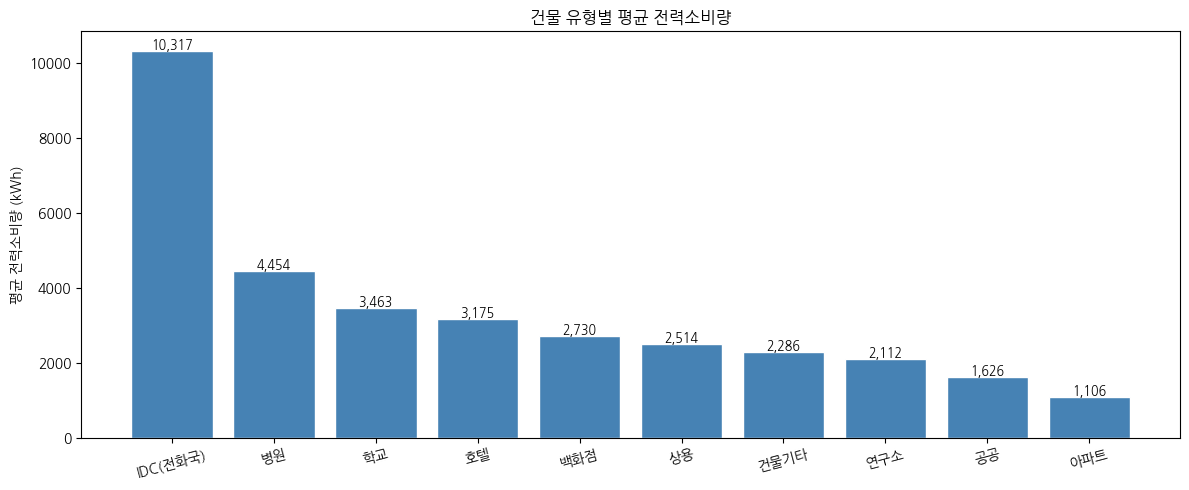

In [ ]:
# building_info 병합
train_merged = train_df.merge(building_df, on='건물번호', how='left')

# 건물 유형별 평균 전력소비량
type_mean = (train_merged.groupby('건물유형')['전력소비량(kWh)']
             .mean()
             .sort_values(ascending=False))

plt.figure(figsize=(12, 5))
bars = plt.bar(type_mean.index, type_mean.values, color='steelblue', edgecolor='white')
plt.title('건물 유형별 평균 전력소비량')
plt.ylabel('평균 전력소비량 (kWh)')
plt.xticks(rotation=15)

# 막대 위에 수치 표시
for bar, val in zip(bars, type_mean.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

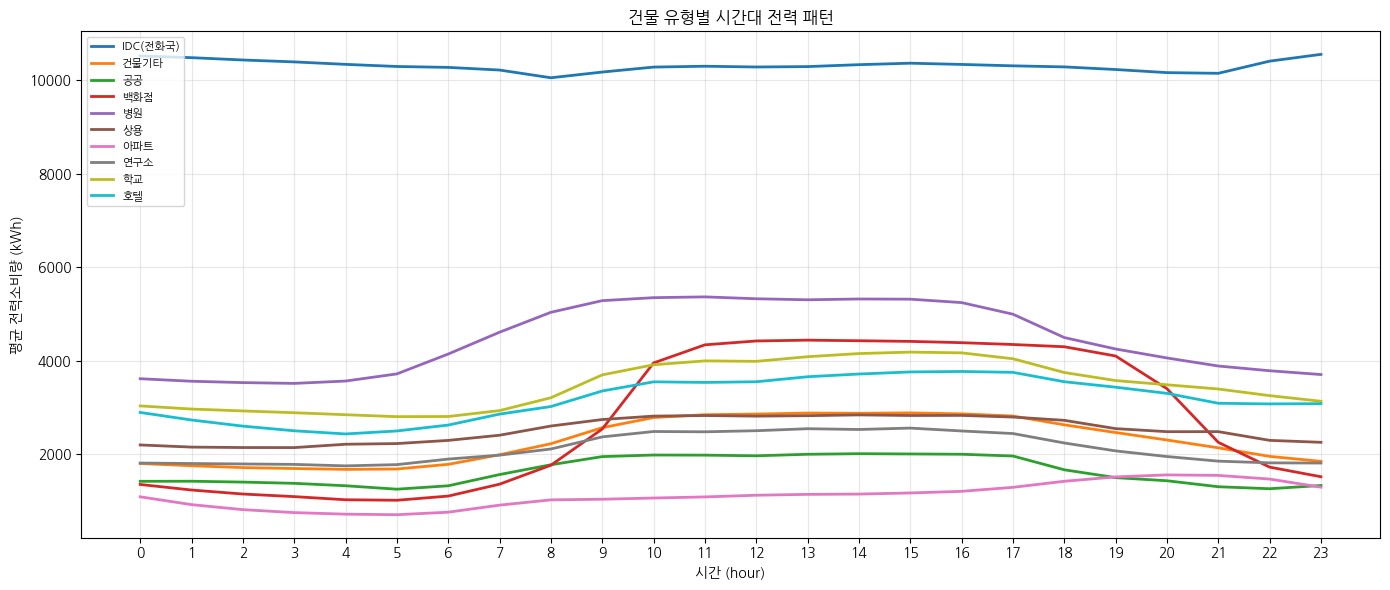

In [ ]:
train_merged['hour'] = train_merged['일시'].apply(lambda x: int(x[9:11]))

# 유형별 × 시간대별 평균
type_hour = (train_merged.groupby(['건물유형', 'hour'])['전력소비량(kWh)']
             .mean().reset_index())

building_types = type_hour['건물유형'].unique()
colors = plt.cm.tab10.colors

plt.figure(figsize=(14, 6))
for i, btype in enumerate(building_types):
    subset = type_hour[type_hour['건물유형'] == btype]
    plt.plot(subset['hour'], subset['전력소비량(kWh)'],
             label=btype, color=colors[i % 10], linewidth=2)

plt.title('건물 유형별 시간대 전력 패턴')
plt.xlabel('시간 (hour)')
plt.ylabel('평균 전력소비량 (kWh)')
plt.xticks(range(0, 24))
plt.legend(loc='upper left', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
train_merged['datetime'] = pd.to_datetime(train_merged['일시'], format='%Y%m%d %H')
train_merged['weekday']  = train_merged['datetime'].dt.weekday
train_merged['is_weekend'] = (train_merged['weekday'] >= 5).astype(int)

# 유형별 평일/주말 차이
weekday_compare = (train_merged.groupby(['건물유형', 'is_weekend'])['전력소비량(kWh)']
                   .mean().unstack())
weekday_compare.columns = ['평일', '주말']
weekday_compare['주말/평일 비율'] = (weekday_compare['주말'] / weekday_compare['평일']).round(2)
weekday_compare = weekday_compare.sort_values('주말/평일 비율')

print('=== 건물 유형별 주말/평일 전력 비율 ===')
print(weekday_compare)

# 비율이 낮을수록 주말에 전력이 크게 줄어드는 건물
# is_weekend feature가 중요한 건물 유형을 확인할 수 있음

=== 건물 유형별 주말/평일 전력 비율 ===
                    평일            주말  주말/평일 비율
건물유형                                          
연구소        2315.960154   1621.379646      0.70
공공         1748.905118   1330.738246      0.76
학교         3661.192388   2986.251942      0.82
병원         4692.871292   3880.909513      0.83
상용         2614.569083   2271.607550      0.87
건물기타       2326.841133   2187.858702      0.94
IDC(전화국)  10378.896269  10168.260656      0.98
백화점        2716.996030   2760.319584      1.02
아파트        1090.641913   1143.910365      1.05
호텔         3123.782967   3297.978500      1.06


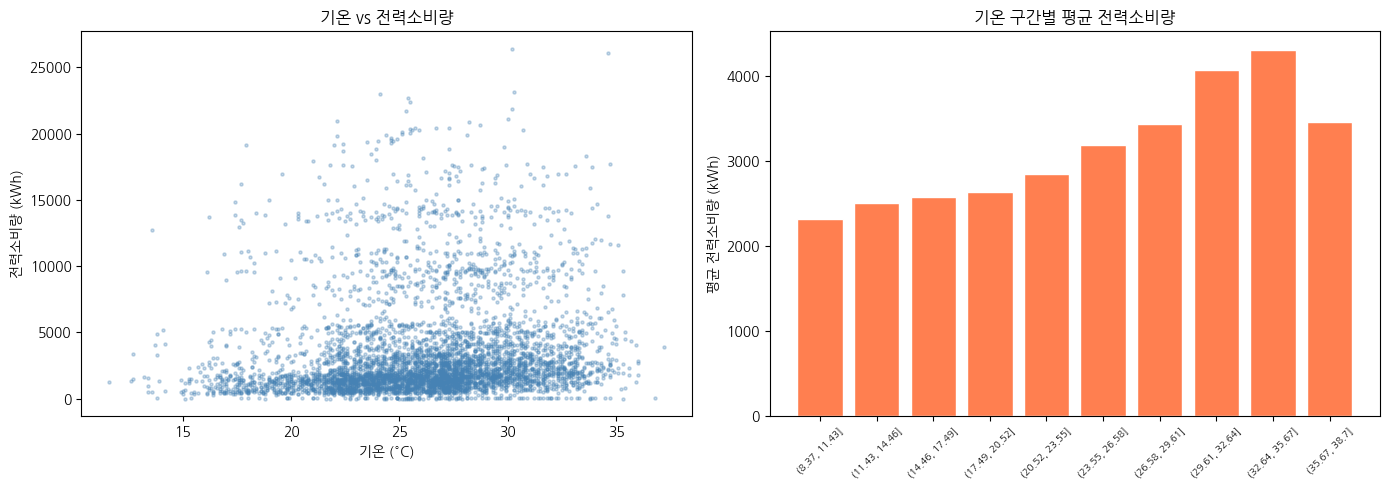

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 기온 vs 전력소비량 산점도 (샘플링해서 그림)
sample = train_merged.sample(5000, random_state=42)
axes[0].scatter(sample['기온(°C)'], sample['전력소비량(kWh)'],
                alpha=0.3, s=5, color='steelblue')
axes[0].set_title('기온 vs 전력소비량')
axes[0].set_xlabel('기온 (°C)')
axes[0].set_ylabel('전력소비량 (kWh)')

# 기온 구간별 평균
train_merged['기온구간'] = pd.cut(train_merged['기온(°C)'], bins=10)
temp_mean = train_merged.groupby('기온구간')['전력소비량(kWh)'].mean()
axes[1].bar(range(len(temp_mean)), temp_mean.values, color='coral', edgecolor='white')
axes[1].set_xticks(range(len(temp_mean)))
axes[1].set_xticklabels([str(x) for x in temp_mean.index], rotation=45, fontsize=7)
axes[1].set_title('기온 구간별 평균 전력소비량')
axes[1].set_ylabel('평균 전력소비량 (kWh)')

plt.tight_layout()
plt.show()